# Machine Learning in Computational Biology
## Spring 2026 • Assignment #1
### Epigenetic Age Prediction from DNA Methylation
Maria-Despoina Liassa


## Task 0 & 1 : Data Loading, EDA and Preprocessing

- The dataset (subset of GSE40279 (Hannum et al., 2013) ) contains DNA methylation beta values (ranging striclty  between from 0 to 1)
    - 0--> unmethylated
    - 1--> methylated
- Each CpG feature (column starting with 'cg') represents the proportion of methylated reads at a specific genomic position

In [1]:
import os
import sys

# 1.Direct to the main root to have access in the folders
sys.path.append(os.path.abspath('../'))
# 2.Import functions from the corresponding file 
from src.functions import create_stratify_bins, data_split
print("The functions are ready for use in the notebook")

The functions are ready for use in the notebook


In [2]:
# Load Libraries
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

### 00_Overwiew of Dataset

In [3]:
# Load data 
file_path = '../data/development_data.csv'
df = pd.read_csv(file_path)

print("Total number of samples:")
print(len(df))

# View the dataframe 
df.head() 


Total number of samples:
456


,sample_id,age,ethnicity,sex,cg16867657,cg06639320,cg24724428,cg07553761,cg22454769,cg06784991,...,cg17321954,cg17783401,cg26483332,cg22730412,cg14704921,cg12179661,cg16780603,cg00588614,cg13039082,cg16640358
0,GSM990554,79,Caucasian - European,M,0.672001,0.504461,0.331257,0.327287,0.572867,0.309496,...,0.174936,0.094635,0.163394,0.304777,0.093110,0.522947,0.736352,0.262954,0.295386,0.350803
1,GSM990278,46,Hispanic - Mexican,M,0.555411,0.389214,0.160708,0.230875,0.464971,0.223665,...,0.154691,0.043087,0.173311,0.343683,0.029271,0.496056,0.801962,0.291890,0.288421,0.318693
2,GSM990589,78,Caucasian - European,M,0.781318,0.554360,0.337578,0.437668,0.645529,0.309615,...,0.213999,0.089760,0.173368,0.338127,0.066988,0.484525,0.588307,0.276745,0.263589,0.344015
3,GSM990323,46,Hispanic - Mexican,F,0.542491,0.435584,0.228723,0.231709,0.493908,0.245836,...,0.198334,0.121145,0.164312,0.394890,0.044809,0.510717,0.736712,0.287274,0.333076,0.303317
4,GSM990116,59,Hispanic - Mexican,F,0.653190,0.466217,0.208453,0.284740,0.592122,0.239320,...,0.147234,0.035716,0.156062,0.341784,0.024294,NaN,0.828072,0.256653,0.322450,0.370363


In [4]:
 #Show summary statistics for all columns, including categorical ones
df.describe(include='all')

,sample_id,age,ethnicity,sex,cg16867657,cg06639320,cg24724428,cg07553761,cg22454769,cg06784991,...,cg17321954,cg17783401,cg26483332,cg22730412,cg14704921,cg12179661,cg16780603,cg00588614,cg13039082,cg16640358
count,456,456.000000,456,456,441.000000,444.000000,444.000000,439.000000,445.000000,442.000000,...,443.000000,445.000000,440.000000,438.000000,439.000000,447.000000,444.000000,449.000000,441.000000,442.000000
unique,456,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GSM990554,NaN,Caucasian - European,M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,308,232,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,64.451754,NaN,NaN,0.672185,0.474773,0.258354,0.306423,0.595564,0.288657,...,0.178872,0.079003,0.159781,0.315001,0.052955,0.503354,0.748769,0.272942,0.295699,0.328856
std,NaN,14.631964,NaN,NaN,0.077055,0.054078,0.075822,0.068490,0.079845,0.050484,...,0.026149,0.037605,0.030063,0.053531,0.029233,0.039453,0.052084,0.034739,0.028885,0.035468
min,NaN,19.000000,NaN,NaN,0.445097,0.282605,0.067115,0.128342,0.334084,0.177003,...,0.123852,0.009463,0.065345,0.091694,0.008391,0.362170,0.443848,0.180870,0.204703,0.112017
25%,NaN,54.000000,NaN,NaN,0.618232,0.438860,0.204332,0.254861,0.548695,0.254821,...,0.161000,0.054660,0.140273,0.281743,0.032664,0.479161,0.714236,0.247651,0.278145,0.309714
50%,NaN,65.000000,NaN,NaN,0.671475,0.474176,0.254157,0.303910,0.592122,0.283393,...,0.177849,0.070133,0.161703,0.317862,0.045958,0.505584,0.751891,0.272034,0.294440,0.332205
75%,NaN,75.250000,NaN,NaN,0.730840,0.509154,0.303655,0.347685,0.647835,0.311986,...,0.193245,0.096696,0.180514,0.348837,0.067091,0.528347,0.782235,0.296712,0.314815,0.351723


In [5]:
print("Shape:", df.shape)  # rows & columns (dataset size)
print("\nData Types:\n", df.dtypes)  # Data types of each column

Shape: (456, 1004)

Data Types:
 sample_id         str
age             int64
ethnicity         str
sex               str
cg16867657    float64
               ...   
cg12179661    float64
cg16780603    float64
cg00588614    float64
cg13039082    float64
cg16640358    float64
Length: 1004, dtype: object


In [6]:
# View number of samples in the dataset 
print("Total number of samples:")
print(len(df))
# View the unique values in Ethnicity 
print("\nUnique values in Ethnicity:")
print(df['ethnicity'].value_counts())
# View the unique values in Sex
print("\nUnique values in Sex:")
print(df['sex'].value_counts())

Total number of samples:
456

Unique values in Ethnicity:
ethnicity
Caucasian - European    308
Hispanic - Mexican      148
Name: count, dtype: int64

Unique values in Sex:
sex
M    232
F    224
Name: count, dtype: int64


### 01_Initial cleaning 
Check for duplicates and delete the column sample_id, since it doesn't provide any predictive value in this project

In [7]:
# Check for duplicates in rows 
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Check for duplicates in columns
print("\nNumber of duplicate columns:")
print(df.columns.duplicated().sum())

# Delete column sample_id as it is not useful for the model
df.drop(columns=['sample_id'], inplace=True)
print("\nColumn 'sample_id' has been dropped")


Number of duplicate rows:
0

Number of duplicate columns:
0

Column 'sample_id' has been dropped


In [8]:
df.head()

,age,ethnicity,sex,cg16867657,cg06639320,cg24724428,cg07553761,cg22454769,cg06784991,cg21572722,...,cg17321954,cg17783401,cg26483332,cg22730412,cg14704921,cg12179661,cg16780603,cg00588614,cg13039082,cg16640358
0,79,Caucasian - European,M,0.672001,0.504461,0.331257,0.327287,0.572867,0.309496,0.444902,...,0.174936,0.094635,0.163394,0.304777,0.093110,0.522947,0.736352,0.262954,0.295386,0.350803
1,46,Hispanic - Mexican,M,0.555411,0.389214,0.160708,0.230875,0.464971,0.223665,0.381837,...,0.154691,0.043087,0.173311,0.343683,0.029271,0.496056,0.801962,0.291890,0.288421,0.318693
2,78,Caucasian - European,M,0.781318,0.554360,0.337578,0.437668,0.645529,0.309615,0.505999,...,0.213999,0.089760,0.173368,0.338127,0.066988,0.484525,0.588307,0.276745,0.263589,0.344015
3,46,Hispanic - Mexican,F,0.542491,0.435584,0.228723,0.231709,0.493908,0.245836,0.424905,...,0.198334,0.121145,0.164312,0.394890,0.044809,0.510717,0.736712,0.287274,0.333076,0.303317
4,59,Hispanic - Mexican,F,0.653190,0.466217,0.208453,0.284740,0.592122,0.239320,0.434244,...,0.147234,0.035716,0.156062,0.341784,0.024294,NaN,0.828072,0.256653,0.322450,0.370363


In [9]:
print("Shape of the dataframe:\n", df.shape)
print("-------")
df.info()

Shape of the dataframe:
 (456, 1003)
-------
<class 'pandas.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Columns: 1003 entries, age to cg16640358
dtypes: float64(1000), int64(1), str(2)
memory usage: 3.5 MB


### 02_Exploratory analysis on raw data

/tmp/ipykernel_2173/367146862.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sex", palette="viridis")


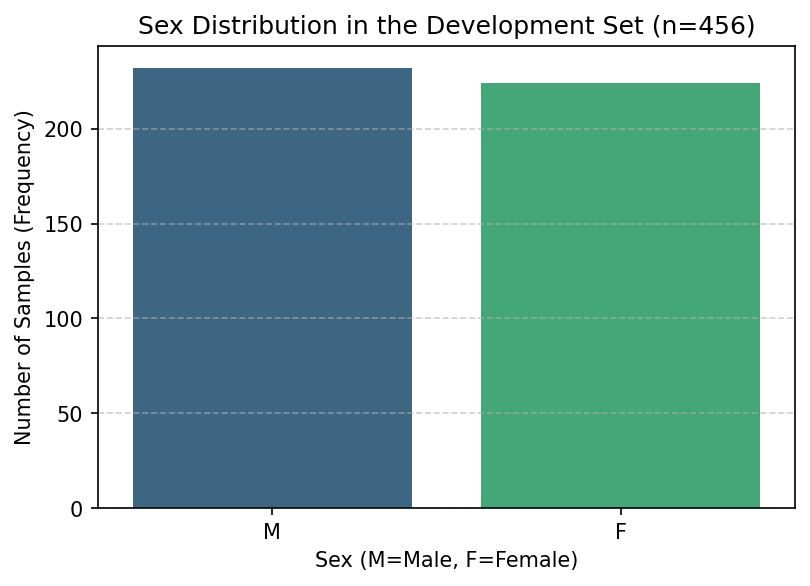

Follow this path to locate the figure: ../figures/Sex Distribution.png


In [10]:
# 150 dpi quality
plt.figure(figsize=(6, 4), dpi=150) 
sns.countplot(data=df, x="sex", palette="viridis") 

# Title & labels
plt.title("Sex Distribution in the Development Set (n=456)", fontsize=12)
plt.xlabel("Sex (M=Male, F=Female)", fontsize=10)
plt.ylabel("Number of Samples (Frequency)", fontsize=10)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Save image in figures
plot_path = '../figures/Sex Distribution.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")

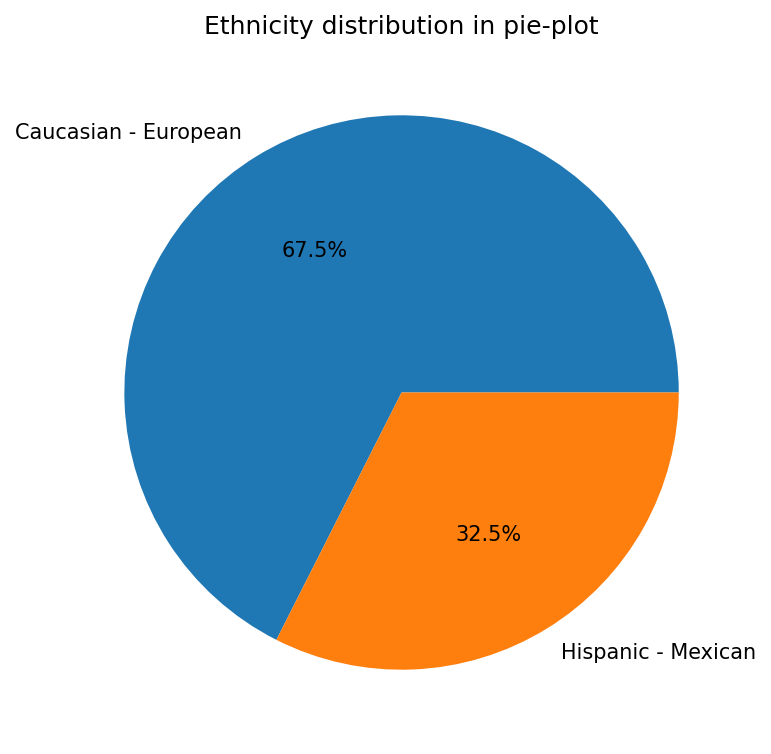

Follow this path to locate the figure: ../figures/Ethnicity distribution.png


In [11]:
# 150 dpi quality
plt.figure(figsize=(8, 6), dpi=150) 
df["ethnicity"].value_counts(normalize=True).plot.pie(autopct="%.1f%%") 

# Title & labels
plt.title("Ethnicity distribution in pie-plot")

# Save image in figures
plot_path = '../figures/Ethnicity distribution.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")

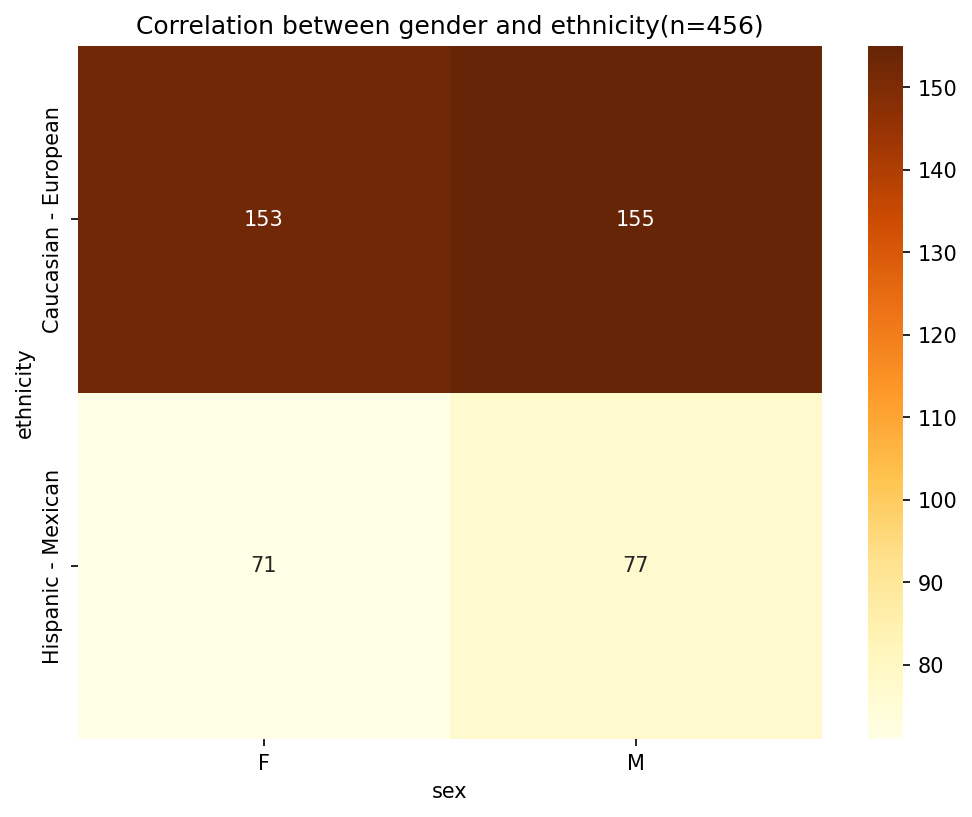

Follow this path to locate the figure: ../figures/Correlation gender-ethnicity.png


In [12]:
# 150 dpi quality
plt.figure(figsize=(8, 6), dpi=150) 
#sns.heatmap(pd.crosstab(df["ethnicity"], df["sex"]), annot=True, fmt="d") 
sns.heatmap(pd.crosstab(df["ethnicity"], df["sex"]), annot=True, fmt="d", cmap="YlOrBr")
# Title & labels
plt.title("Correlation between gender and ethnicity(n=456)", fontsize=12)

# Save image in figures
plot_path = '../figures/Correlation gender-ethnicity.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")

Unique values in Sex: <StringArray>
['M', 'F']
Length: 2, dtype: str
Unique values in Ethnicity: <StringArray>
['Caucasian - European', 'Hispanic - Mexican']
Length: 2, dtype: str


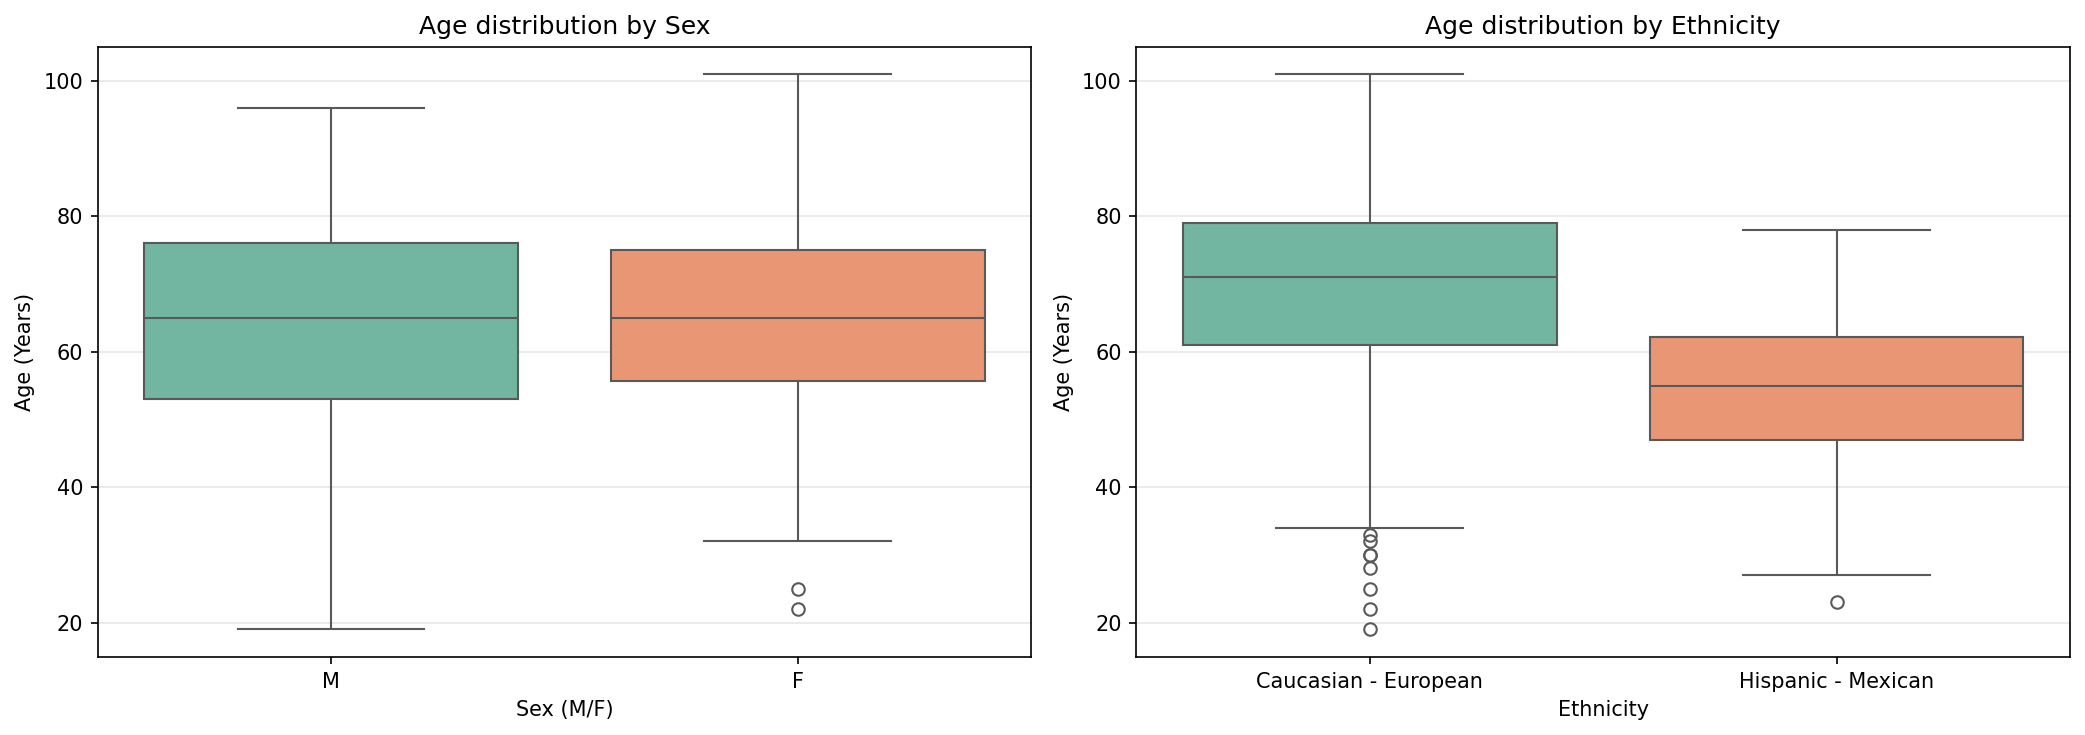

Follow this path to locate the figure: ../figures/Age-Sex-Ethnicityn.png


In [13]:
# Take unique values
print("Unique values in Sex:", df['sex'].unique())
print("Unique values in Ethnicity:", df['ethnicity'].unique())

# Subplots with 150 dpi quality
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Title & labels
# Age-Sex Boxplot
sns.boxplot(x='sex', y='age', data=df, ax=ax1, palette="Set2", hue='sex', legend=False)
ax1.set_title('Age distribution by Sex')
ax1.set_xlabel('Sex (M/F)')
ax1.set_ylabel('Age (Years)')
# Grid
ax1.grid(axis='y', alpha=0.3)

# Age-Ethnicity Boxplot
sns.boxplot(x='ethnicity', y='age', data=df, ax=ax2, palette="Set2", hue='ethnicity', legend=False)
ax2.set_title('Age distribution by Ethnicity')
ax2.set_xlabel('Ethnicity')
ax2.set_ylabel('Age (Years)')
# Grid
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout() 
# Save figure
plot_path = '../figures/Age-Sex-Ethnicityn.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")

We take the unique values to see (again) if there are any missing values in those features and to ensure the names of the values in those features
- The age distribution is similar between the two genders in the present dataset, ensuring that the models will not exhibit bias due to an imbalance of age groups between men and women
- A clear divergence in the age distribution is observed between the two ethnic groups of the data
- The Caucasian - European group presents a higher median age (approximately 70 years) and a narrower range of values, concentrated in older ages. In contrast, the Hispanic - Mexican group presents a lower median age (approximately 55 years) with a greater dispersion towards younger ages

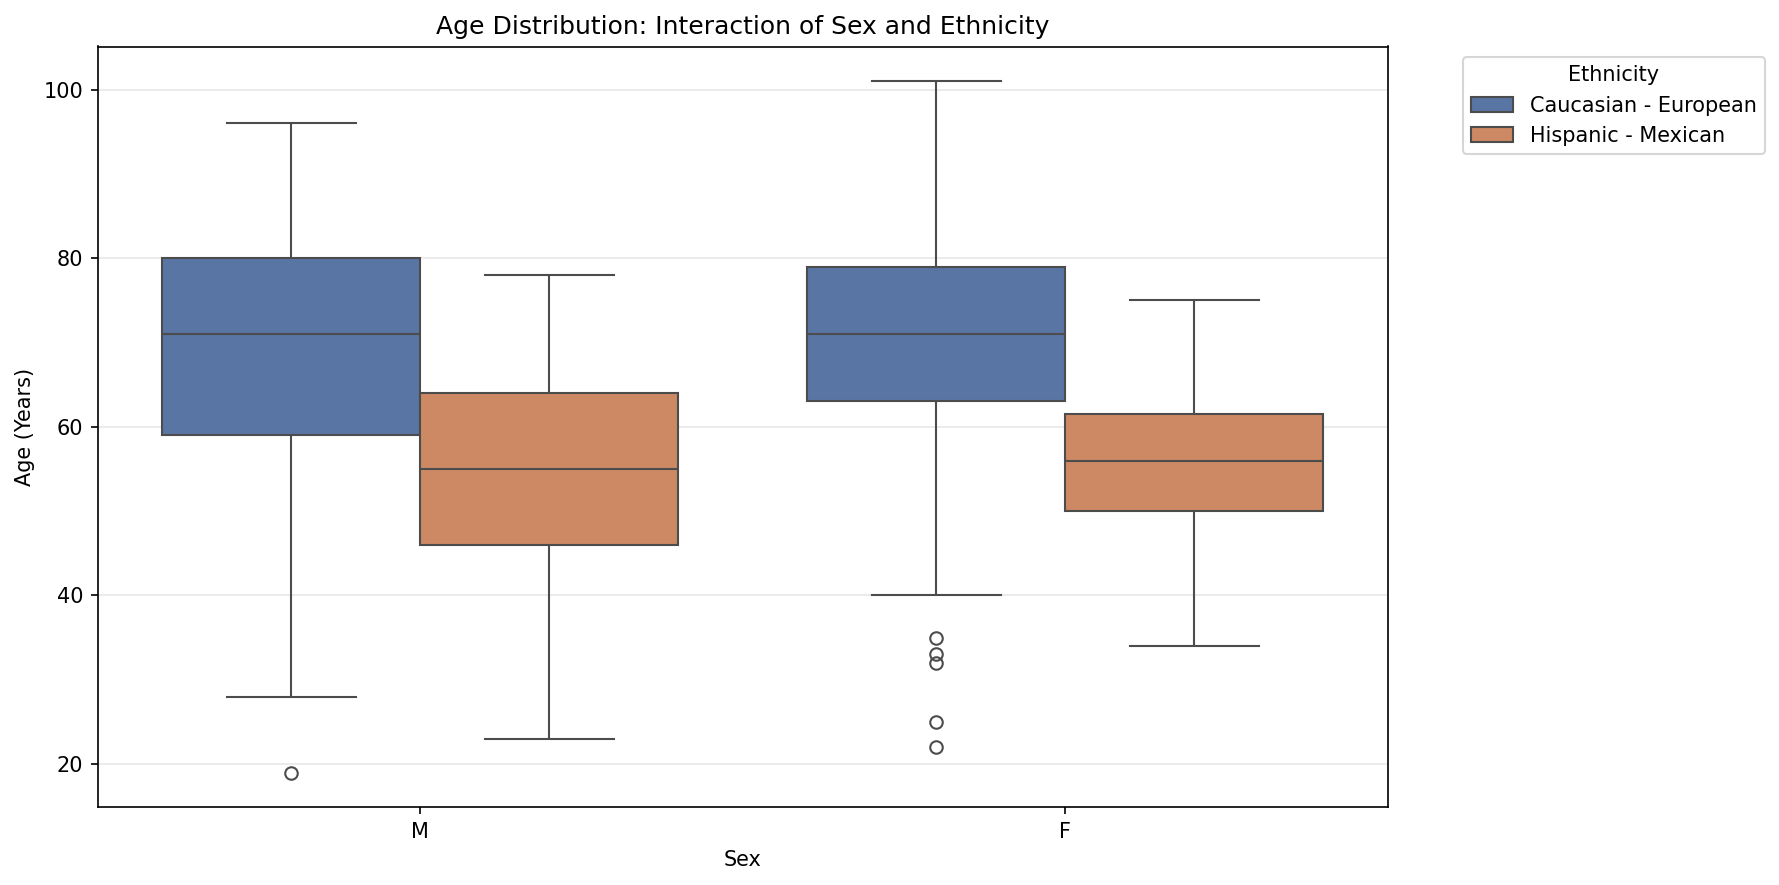

Follow this path to locate the figure: ../figures/Distribution Age-Sex-Ethnicityn.png


In [14]:
# 150 dpi quality
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
sns.boxplot(x='sex', y='age', hue='ethnicity', data=df, ax=ax, palette="deep")

# Title & labels
ax.set_title('Age Distribution: Interaction of Sex and Ethnicity')
ax.set_xlabel('Sex')
ax.set_ylabel('Age (Years)')

# Grid
ax.grid(axis='y', alpha=0.3)
# Legend
ax.legend(title='Ethnicity', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout() 

# Save figure
plot_path = '../figures/Distribution Age-Sex-Ethnicityn.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")
plt.show()

count    456.000000
mean      64.451754
std       14.631964
min       19.000000
25%       54.000000
50%       65.000000
75%       75.250000
max      101.000000
Name: age, dtype: float64


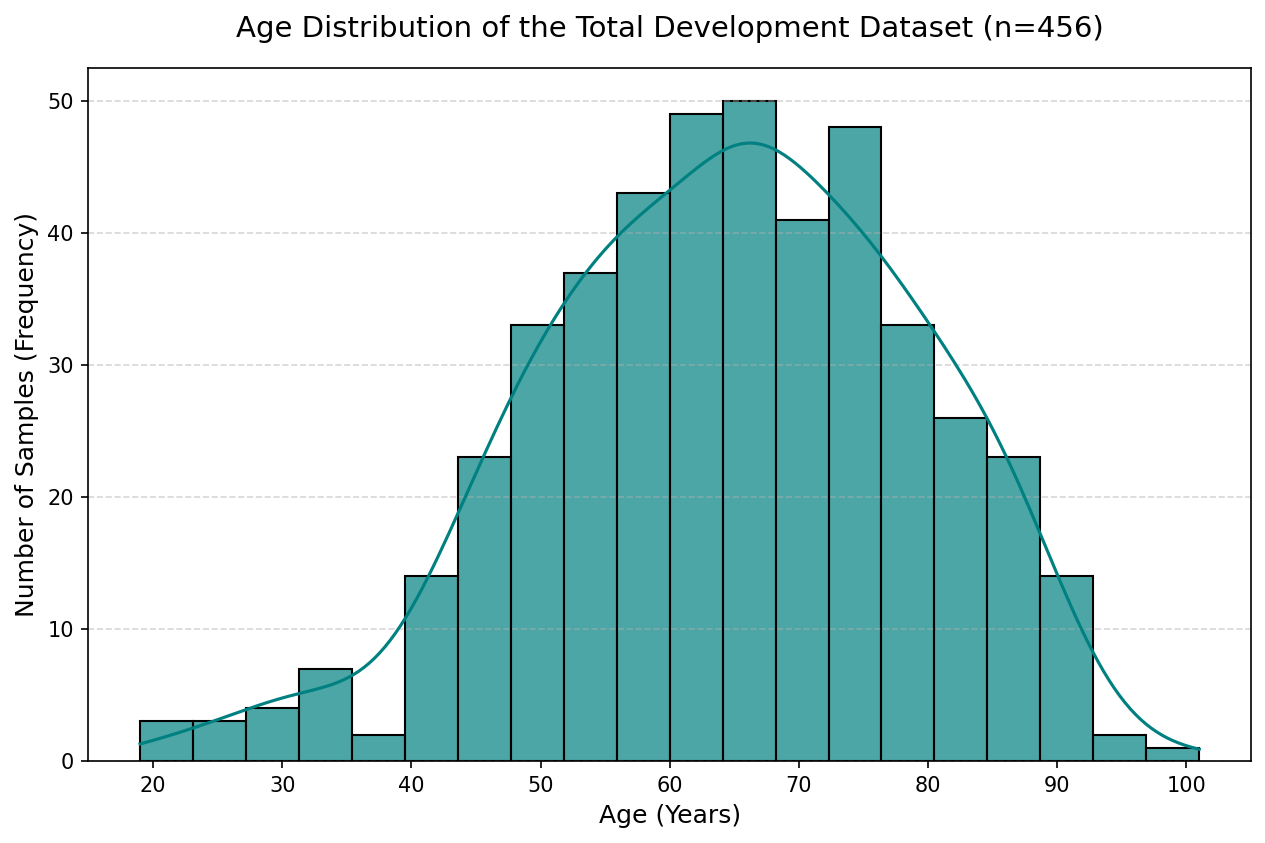

Follow this path to locate the figure: ../figures/age_distribution.png


In [15]:
# Age Statistics
print(df['age'].describe())

# Age Distribution 
# 150 dpi quality
plt.rcParams['figure.dpi'] = 150
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], kde=True, color='teal', bins=20, edgecolor='black', alpha=0.7)

# Title & labels 
plt.title('Age Distribution of the Total Development Dataset (n=456)', fontsize=14, pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Number of Samples (Frequency)', fontsize=12)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xlim(15, 105)

# Save image in figures
plot_path = '../figures/age_distribution.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")

Before splitting the data, we need to take a look at the distribution of the class. We observe that dataset forms a Normal Distribution with a right skew. This means that the majority of the data are repserented by elderly people, there are less data for people between 20-45 years old. However there are data for all age groups. This imbalance in the classes is a strong indication to use stratified splitting

### 03_Search for missing values

- Before the preprocessing we need to investigate the values of the data per column and the nature of missing values 
- Since the missing values are random, we need to ckeck if they are numeric or/and categorical, to deal with them appropriately

In [16]:
# Check for missing values in numerical columns
# 1.Total missing values per coolumn
missing_counts = df.isnull().sum()

# 2. Filter columns and get those that have at least 1 missing value
missing_only = missing_counts[missing_counts > 0]

# 3. Percentage calculation
missing_percentage = (missing_only / len(df)) * 100

# 4. Print results in a dataframe
missing_info = pd.DataFrame({
    'Missing Values': missing_only,
    'Percentage (%)': missing_percentage
}).sort_values(by='Missing Values', ascending=False)

print(f"Number of CgPs with missing values:{(df.isnull().sum() > 0).sum()}")

print("\nColumns with missing values:")
if missing_info.empty:
    print("There is no column with missing values")
else:
    print(missing_info)

# Check for missing values in categorical columns
print("\nCategorical columns:")
for col in ['sex', 'ethnicity','age']:
    print(f"{col}: {df[col].isnull().sum()} missing")

Number of CgPs with missing values:1000

Columns with missing values:
            Missing Values  Percentage (%)
cg26330518              32        7.017544
cg25410668              28        6.140351
cg15903032              25        5.482456
cg01493685              25        5.482456
cg12233363              25        5.482456
...                    ...             ...
cg19804488               4        0.877193
cg25236230               4        0.877193
cg22512670               4        0.877193
cg20469744               4        0.877193
cg16431787               4        0.877193

[1000 rows x 2 columns]

Categorical columns:
sex: 0 missing
ethnicity: 0 missing
age: 0 missing


- Missing values are detected only in the CpG columns varying between 0.8 % to 7% 
- However the impresive is that we have missing values to ALL the CgP columns
- Even if deleteting missing values is an approach, imputing is prefereable
- Need to decide whether the median or mean is the more appropriate approach of missing values replacemnt for this dataset. 
    - Median is a robust measure in an ordered dataset which makes it a preferable candidate if the dataset has strong indications of outliers. This is because median represents a stable point within a distribution
    - Mean  is used more often in normal distributed data, where there is not skewness which implies outliers in the data
- Let's investigate which option is more suitable for this dataset 

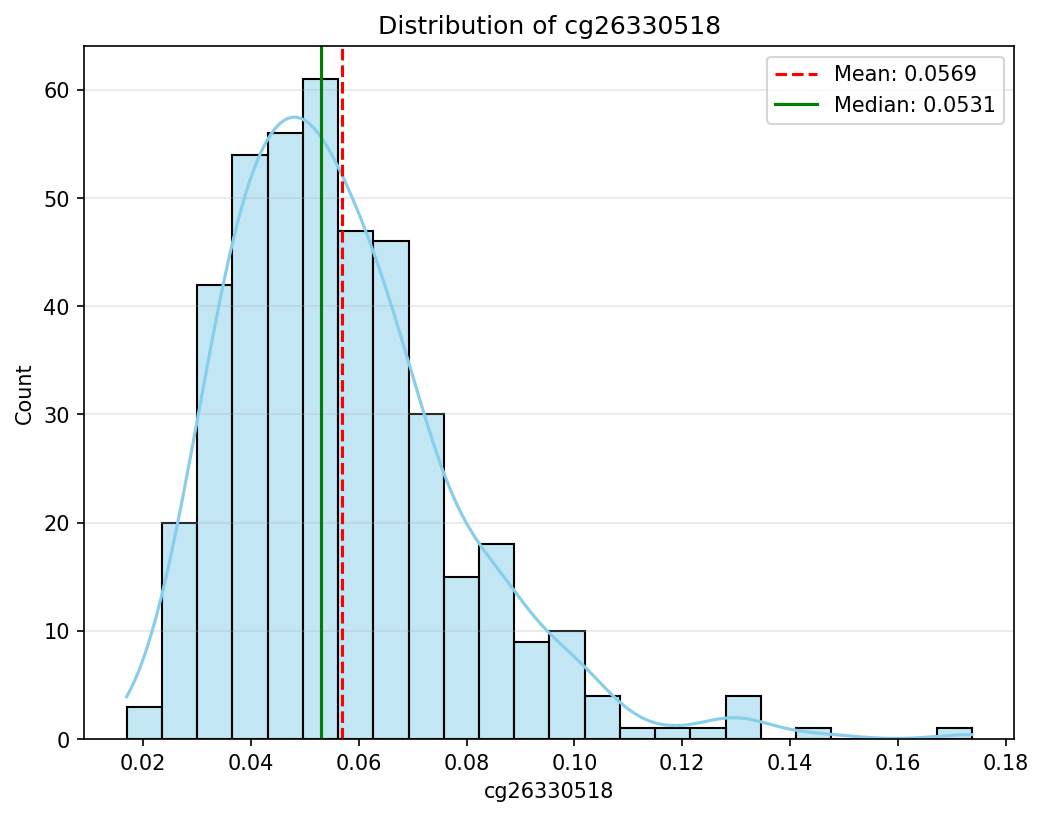

Follow this path to locate the figure: ../figures/cg26330518 Distribution.png


In [17]:
# Use column cg26330518 which has the higher amount of missing values 
cpg_col = 'cg26330518'

# 150 dpi quality
plt.figure(figsize=(8, 6), dpi=150) 
sns.histplot(df[cpg_col].dropna(), kde =True, color='skyblue')

# Calculate Mean & Median
plt.axvline(df[cpg_col].mean(), color='red', linestyle='--', label=f'Mean: {df[cpg_col].mean():.4f}')
plt.axvline(df[cpg_col].median(), color='green', linestyle='-', label=f'Median: {df[cpg_col].median():.4f}')

# Title & labels
plt.title(f'Distribution of {cpg_col}')

# Grid & Legend
plt.grid(axis='y', alpha=0.3)
plt.legend()

# Save image in figures
plot_path = '../figures/cg26330518 Distribution.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")


In [18]:
# Calculate skewness only for CgP columns with missing values
cols_with_missing = missing_info.index
all_skews = df[cols_with_missing].skew()

# Skewness statistics
print("Statistic Skewness for CgP with missing values:")
print(all_skews.describe())

# Number of CgPs with strong skewness (> 1 ή < -1);
high_skew = all_skews[(all_skews > 1) | (all_skews < -1)]
print(f"\nCgPs with strong skewness: {len(high_skew)} out of {len(cols_with_missing)}")

Statistic Skewness for CgP with missing values:
count    1000.000000
mean        0.075248
std         0.960081
min        -5.736891
25%        -0.437509
50%        -0.092593
75%         0.356041
max         7.835384
dtype: float64

CgPs with strong skewness: 171 out of 1000


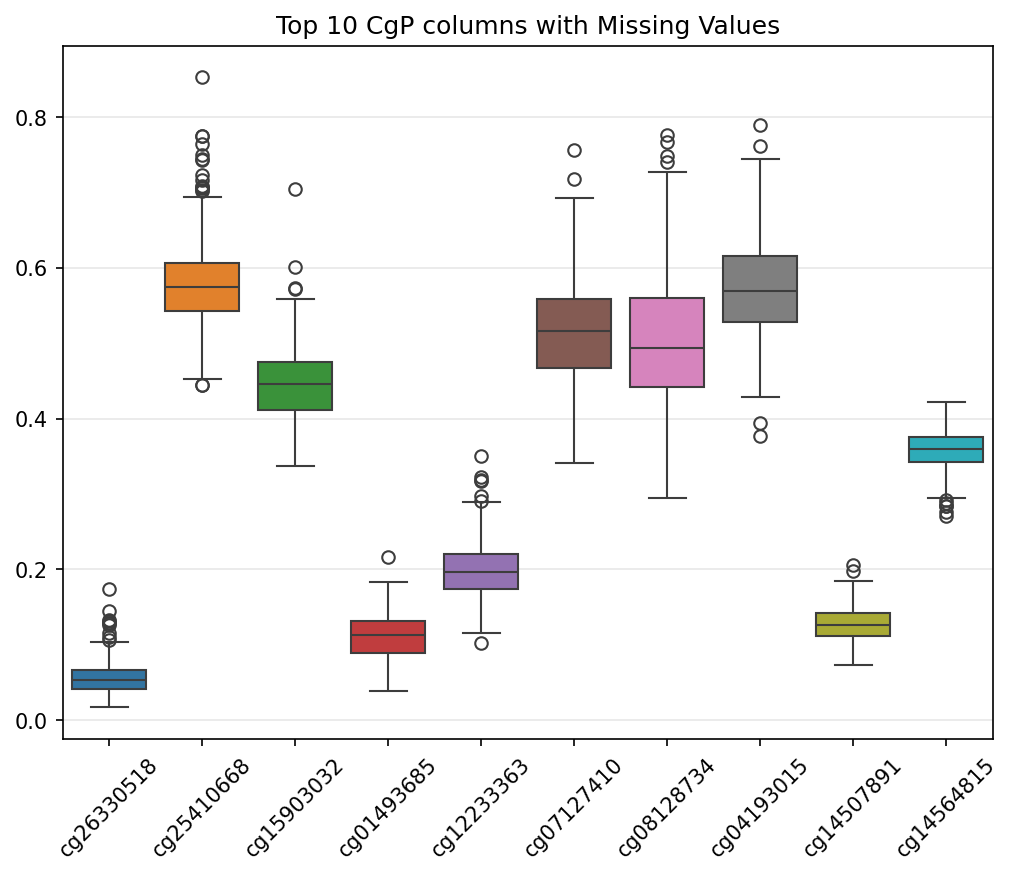

Follow this path to locate the figure: ../figures/Top CgP columns with Missing Values.png


In [19]:
top_10_missing = missing_info.head(10).index

# 150 dpi quality
plt.figure(figsize=(8, 6), dpi=150) 
sns.boxplot(data=df[top_10_missing])

# Title & labels
plt.xticks(rotation=45)
plt.title("Top 10 CgP columns with Missing Values")

# Grid
plt.grid(axis='y', alpha=0.3)

# Save image in figures
plot_path = '../figures/Top CgP columns with Missing Values.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")


- The distribution of values above, pictures that  Median and Mean are almost identical, which initially indicated that using Mean is currently a safe approach and it won't affect downstream Analysis
- However skewness analysis across all 1,000 CpG sites revealed that 17.1% of the features exhibit strong skewness (ranging from -5.7 to 7.8). Whivh is also confirmed by boxplot visualization that reveal the presence of significant outliers in several features. To ensure robustness against these outliers and prevent biased estimations, the Median Imputation strategy was adopted as the most appropriate method for this dataset
- However Median will be calculated by Training set(X_train) only to avoid data leakage. Otherwise if we would applied imputing before splitting or calculating by the whole sataset, values from validation set would impact the calculation  

- CgP columns represent the percentage of methylation on DNA positions and their values are the mean of methylation calculated by the all the cells  on this position 

## 1. Pre-processing

### 1.1 Data Splitting 

### Create bins for Age for stratified by age splitting

In [20]:
# Call function to create age bins for stratification
bins = create_stratify_bins(df['age'], num_bins=4)
# bins is a list of the same length as df, which is used to stratify the data when splitting into training and validation sets
# this ensures that the age distribution is similar in both sets, which is important for model performance and generalization
# also is not added as a column to the dataframe, it is only used for stratification during the split

# Split the data into training and validation sets using the data_split function
train_df, val_df = data_split(df, stratify_col=bins)

In [21]:
# Check the lack of the column 'age_bins' in the training and validation sets, as it is not added to the dataframe but only used for stratification 
print("Is there 'age_bins' in train_df?", 'age_bins' in train_df.columns)
print("Is there 'age_bins' in val_df?", 'age_bins' in val_df.columns)


Is there 'age_bins' in train_df? False
Is there 'age_bins' in val_df? False


In [22]:
# View the bins and the age distribution in the original dataframe
print("Age bins:\n" , bins)
print("--------------------------")
print("Age distribution:\n", df['age'])

Age bins:
 [3 2 3 2 2 3 4 3 4 2 3 2 4 1 3 2 2 3 3 3 3 2 3 4 3 3 3 1 3 3 2 4 4 2 2 3 3
 3 4 2 3 3 3 2 1 2 2 3 2 4 3 3 3 2 4 4 3 3 3 2 2 3 2 3 3 3 3 2 3 3 3 2 3 2
 2 3 2 3 3 2 3 2 2 3 3 3 3 3 3 3 4 4 1 3 4 2 3 4 3 2 2 2 4 2 3 3 2 2 2 1 2
 2 4 3 3 4 4 3 3 2 4 3 3 3 2 3 3 4 2 3 3 3 3 3 2 3 3 4 2 3 1 3 3 3 3 2 3 3
 2 3 3 3 2 3 2 3 2 4 3 2 3 3 3 4 2 3 3 3 2 2 3 2 2 3 3 2 3 2 2 3 1 2 2 3 3
 2 1 3 2 3 3 2 3 4 4 1 2 1 3 3 3 3 3 2 3 1 1 3 2 3 2 2 4 3 3 4 2 2 4 4 2 2
 4 4 3 3 4 2 3 4 2 2 3 3 4 3 2 4 3 2 4 2 4 3 2 3 3 4 4 2 2 3 3 4 3 3 2 3 3
 4 2 1 3 2 4 3 1 3 4 3 3 3 2 2 4 2 2 3 4 3 2 3 3 3 2 3 2 3 3 3 3 3 2 2 3 3
 2 3 3 2 3 3 4 3 2 3 2 3 3 3 2 2 2 2 3 1 3 3 2 2 3 3 2 2 3 3 2 4 4 3 3 2 3
 3 3 2 2 2 3 4 3 3 4 2 3 3 3 4 2 3 3 3 3 2 2 3 3 3 3 2 2 2 3 3 3 2 2 2 2 2
 3 4 2 2 3 3 1 3 4 2 3 3 3 4 2 4 2 4 3 3 2 3 2 3 3 2 3 3 3 3 4 4 3 2 3 3 3
 3 2 2 2 2 2 3 2 3 2 2 2 3 4 3 4 2 1 2 3 1 2 2 3 2 4 3 2 2 3 3 3 4 3 4 3 2
 3 4 1 3 2 2 4 3 3 4 2 3]
--------------------------
Age distribution:
 0      79
1      

We created 4 bins to correlate the age groups : 
- bin 1 stands for young people
- bin 2 stands for middle aged people
- bin 3 stands for elderly people
- bin 4 stands for very elderly people


In [23]:
# Check the split statistics for the training and validation sets
from src.functions import get_split_stats

train_stats = get_split_stats("Training Set", train_df)
val_stats = get_split_stats("Validation Set", val_df)

df_stats = pd.DataFrame([train_stats, val_stats])

print("Dataset Statistics per Split:")
display(df_stats)

Dataset Statistics per Split:


,Split,n (Samples),Age (Mean ± Std),Age Range,Sex Balance (% Male)
0,Training Set,364,64.34 ± 14.71,19 - 101,51.1%
1,Validation Set,92,64.88 ± 14.38,27 - 92,50.0%


In [24]:
# Choose the fearures and the label column to separate the data
# Exclude 'age' cause this is the target & sample_id' cause is not useful for prediction
target_col='age'

X_train = train_df.drop(columns=[target_col]) 
y_train=train_df[target_col]

X_val = val_df.drop(columns=[target_col])
y_val = val_df[target_col]

# Validate that the splitting is 80-20
print(f"X_train shape: {X_train.shape} (this is the number of samples and features in the training set)")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape} (this is the number of samples and features in the validation set)")
print(f"y_val shape: {y_val.shape}")

X_train shape: (364, 1002) (this is the number of samples and features in the training set)
y_train shape: (364,)
X_val shape: (92, 1002) (this is the number of samples and features in the validation set)
y_val shape: (92,)


In [25]:
from src.functions import get_split_stats

import pandas as pd

# Fill a list with the values calculated my the get_split_stats function
stats_list = [
    get_split_stats('Training', train_df),
    get_split_stats('Validation', val_df),
    get_split_stats('Total Development', df)
]

# Create a dataframe to load the values
stats_table = pd.DataFrame(stats_list)

print("--- Task 1: Dataset Statistics Table ---")
display(stats_table)

--- Task 1: Dataset Statistics Table ---


,Split,n (Samples),Age (Mean ± Std),Age Range,Sex Balance (% Male)
0,Training,364,64.34 ± 14.71,19 - 101,51.1%
1,Validation,92,64.88 ± 14.38,27 - 92,50.0%
2,Total Development,456,64.45 ± 14.63,19 - 101,50.9%


### 1.2 Preprocessing 

- Since τhe dataset contains 1000 features and only ~400 samples. For this reason dimensionality reduction is necessary
- With this tactic we avoid future overfitting and models will be trained on the general age patterna and no noise,  obtaining better generalisation behavior 

- As prooved the more appropriate approach for imputing this dataset is the 'median'  
- StandardScaler used for scaling the data
- One-Hot-Encoding was chosen to transform categorical data into their numeric form. Also, Label Encoding might feels like a satisfying method, since it assigns each category of a categorical variable a unique integer value and is preferable for memory efficiency. This converts the categorical column into a single numerical feature. But that's not the case here, since this method is suitable for ordinal data only, cause it assumes that there is an order between the them

- The get_preprocessing_pipeline function is designed to handle the high-dimensional CpG features (numeric) and metadata (categorical) through a unified ColumnTransformer
- The integration of Principal Component Analysis **(PCA) within the numeric pipeline is controlled by the n_components parameter** :
    - Exploration Stage (n_components=None): By passing None, the function initializes a standard PCA that calculates all possible components. This is used to generate an Elbow Plot, allowing us to visualize the cumulative explained variance and determine the optimal number of PCs.
    - Dimensionality Reduction (n_components=k): Once the optimal number is decided (e.g., k=200$), the function is called again with this integer value to compress the 1000+ CpG features into k principal components, reducing noise and computational cost
    - Bypassing PCA (n_components='passthrough'): If the goal is to evaluate models on the raw, scaled features (e.g., for Task 2.2), setting the parameter to 'passthrough' triggers a conditional check. This replaces the PCA step with a FunctionTransformer (identity mapping), effectively ignoring the dimensionality reduction while ensuring all other steps—like Median Imputation and Standard Scaling—are still consistently applied to the CpG columns

In [26]:
from sklearn.decomposition import PCA       
from src.functions import get_preprocessing_pipeline

# 1. Preparation of columns
cpg_cols = [col for col in X_train.columns if col.startswith('cg')]
cat_cols = ['sex', 'ethnicity']

# 2. Initial Fit for the Elbow Plot (n_components=None)
# Here the pipeline handles both scaling and PCA internally
pca_explorer = get_preprocessing_pipeline(cpg_cols, cat_cols, n_components=None)
pca_explorer.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

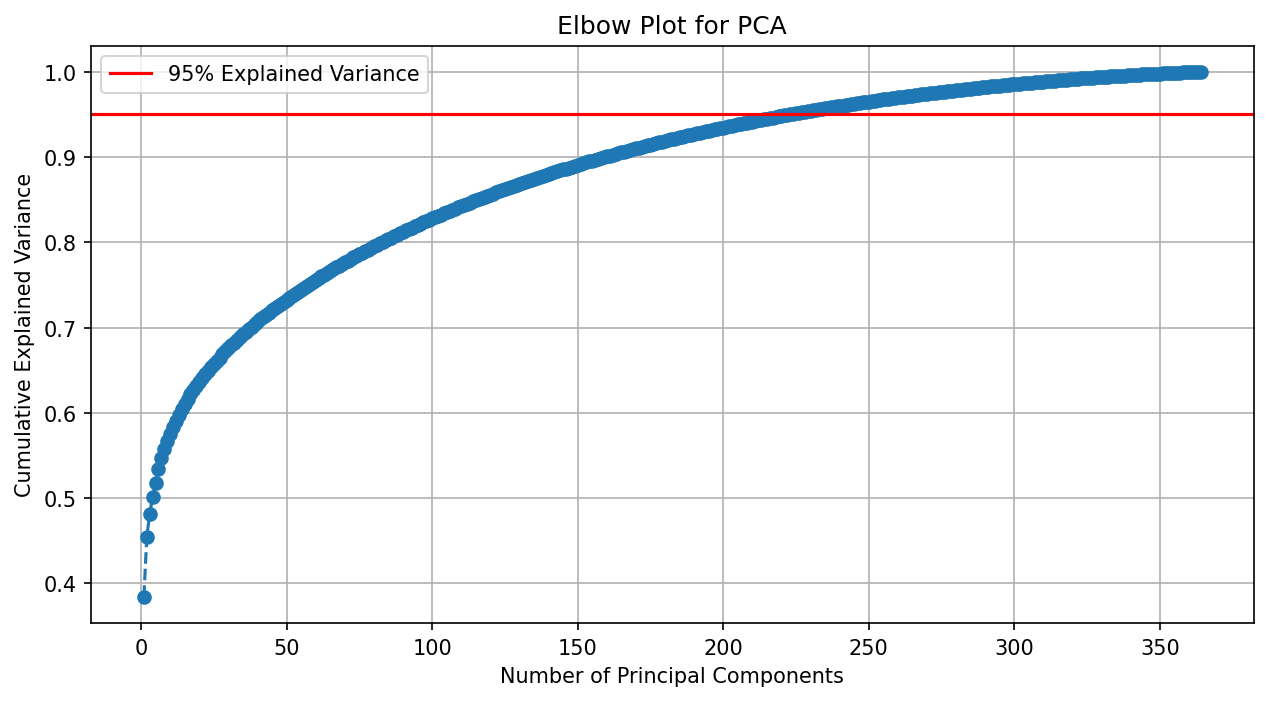

Follow this path to locate the figure: ../figures/Elbow Plot PCA.png


In [27]:
# 3. Get the trained PCA from the pipeline located under 'num' transformer
num_pipeline = pca_explorer.named_transformers_['num']
pca_step = num_pipeline.named_steps['pca']

# 4. Calculate Cumulative Explained Variance
exp_var_ratio = pca_step.explained_variance_ratio_
cum_var = np.cumsum(exp_var_ratio)

# 5. Plotting Elbow Plot with explained variance for the PCA to determine the optimal number of components
# 150 dpi quality
plt.figure(figsize=(10, 5), dpi=150)
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', linestyle='--')

# Title & labels
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Elbow Plot for PCA')

# Grid & Legend
plt.legend()
plt.grid()

# Save image in figures
plot_path = '../figures/Elbow Plot PCA.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")


- Observing the Elbow plot, we can see that keeping 200 PCs explains the 95% of variation. This decision keeps the 200 most informative features of CpG
out of the 1000 we had initially, which reduce noise and will help the Regressors to be trained faster but effectively on the most important CgP features
- **However, we're going to follow the instructions of the assignment and we will not apply PCA --> k = 'passthrough'** . We only did this to have a better understanding of the dataset and for potential future use  (in case we want to apply PCA in the raw data before modeling, during the pre processing stage)

In [ ]:
# 3.  Determine the Final Pipeline (where k is the number of components chosen from the Elbow Plot or set to 'passthrough' if we decide not to apply PCA)
k = 'passthrough' 
final_processor = get_preprocessing_pipeline(cpg_cols, cat_cols, n_components=k)

# 4. Execution - Get the final transformed data directly
# Fit is applied only to X_train
X_train_final = final_processor.fit_transform(X_train)
# The transform on X_val uses the parameters from X_train
X_val_final = final_processor.transform(X_val)

## 1.3 Exploratory Analysis on the processed data

In [29]:
# Check for NaN values in the final processed training data
nan_count = np.isnan(X_train_final).sum()
print(f"Number of missing values: {nan_count}")

Number of missing values: 0


In [30]:
from src.functions import get_split_stats

import pandas as pd

# Fill a list with the values calculated my the get_split_stats function
stats_list = [
    get_split_stats('Training', train_df),
    get_split_stats('Validation', val_df),
    get_split_stats('Total Development', df)
]

# Create a dataframe to load the values
stats_table = pd.DataFrame(stats_list)

print("--- Task 1: Dataset Statistics Table ---")
display(stats_table)

--- Task 1: Dataset Statistics Table ---


,Split,n (Samples),Age (Mean ± Std),Age Range,Sex Balance (% Male)
0,Training,364,64.34 ± 14.71,19 - 101,51.1%
1,Validation,92,64.88 ± 14.38,27 - 92,50.0%
2,Total Development,456,64.45 ± 14.63,19 - 101,50.9%


In [31]:
print("Shape:", df.shape)  # How many rows and columns (dataset size)
print("\nData Types:\n", df.dtypes)  # Data types of each column

Shape: (456, 1003)

Data Types:
 age             int64
ethnicity         str
sex               str
cg16867657    float64
cg06639320    float64
               ...   
cg12179661    float64
cg16780603    float64
cg00588614    float64
cg13039082    float64
cg16640358    float64
Length: 1003, dtype: object


In [32]:
print("--- Final Dimension (Processed) ---")
print(f"X_train_final shape: {X_train_final.shape}") # Expected: (samples, 200 + cat_cols)
print(f"y_train shape:       {y_train.shape}")       # Expected: (samples,)
print(f"X_val_final shape:   {X_val_final.shape}")   # Expected: (samples_val, 200 + cat_cols)
print(f"y_val shape:         {y_val.shape}")         # Expected: (samples_val,)

--- Final Dimension (Processed) ---
X_train_final shape: (364, 1002)
y_train shape:       (364,)
X_val_final shape:   (92, 1002)
y_val shape:         (92,)


In [33]:
# --- After the Processing ---
print("\n--- After the Processing (Final processor) ---")

# Total columns in the final processed training data
total_cols = X_train_final.shape[1]

# Calculate how many columns come from the categorical metadata after encoding 
cat_transformer = final_processor.named_transformers_['cat']
encoded_cat_names = cat_transformer.get_feature_names_out(cat_cols)
num_cat_features = len(encoded_cat_names)

# The remaining columns are necessarily the CpG columns (either through PCA or passthrough)
num_cpg_features = total_cols - num_cat_features

print(f"Columns from CpG (Numeric):    {num_cpg_features}") 
print(f"Columns from Metadata (Encoded): {num_cat_features}")
print(f"Total columns in X_train_final: {total_cols}")

# Verification
if k == 'passthrough':
    print(f"\nVerification: Current CpG count ({num_cpg_features}) should match raw CpG count ({len(cpg_cols)})")


--- After the Processing (Final processor) ---
Columns from CpG (Numeric):    1000
Columns from Metadata (Encoded): 2
Total columns in X_train_final: 1002

Verification: Current CpG count (1000) should match raw CpG count (1000)


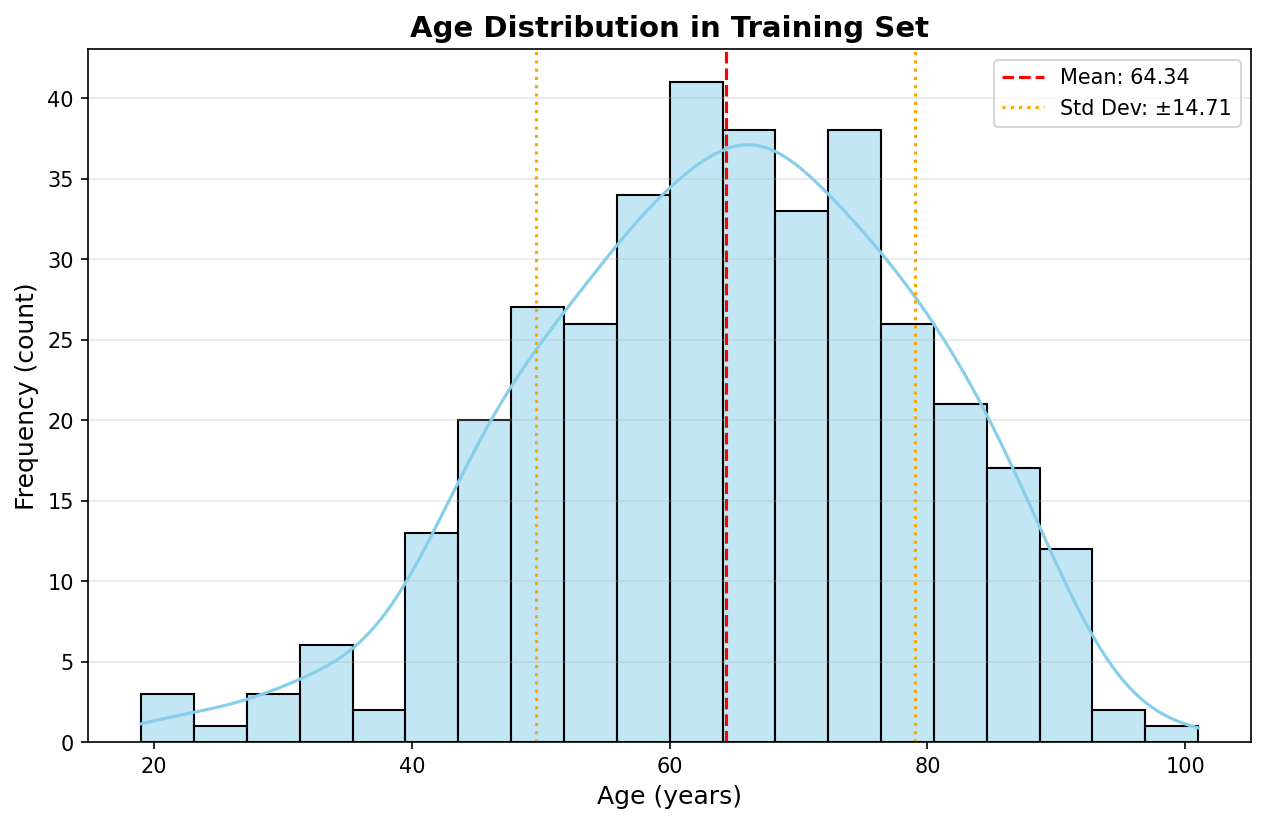

Follow this path to locate the figure: ../figures/Age_Distribution aftersplit.png


In [34]:
# 150 dpi quality
plt.figure(figsize=(10, 6), dpi=150)

# CCalculate statistics for age in the training set
mean_age = train_df['age'].mean()
std_age = train_df['age'].std()
min_age = train_df['age'].min()
max_age = train_df['age'].max()

# Create plot
sns.histplot(train_df['age'], kde=True, color='skyblue', bins=20)

# Add vertical lines for mean and standard deviation
plt.axvline(mean_age, color='red', linestyle='--', label=f'Mean: {mean_age:.2f}')
plt.axvline(mean_age - std_age, color='orange', linestyle=':', label=f'Std Dev: ±{std_age:.2f}')
plt.axvline(mean_age + std_age, color='orange', linestyle=':')

# Title & labels
plt.title('Age Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Frequency (count)', fontsize=12)

# Grid & Legend
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Save image in figures
plot_path = '../figures/Age_Distribution aftersplit.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")

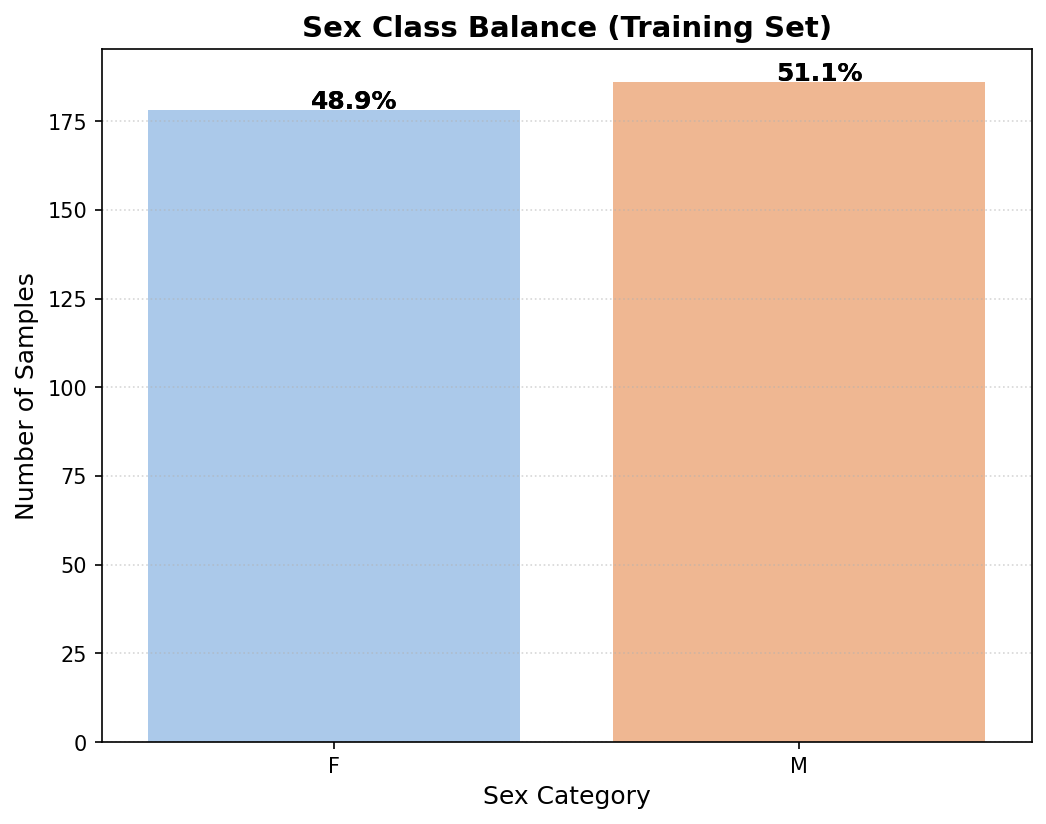

Follow this path to locate the figure: ../figures/Sex_Class_Balance aftersplit.png


In [35]:
# 150 dpi quality
plt.figure(figsize=(8, 6), dpi=150)

# Create count plot for sex distribution in the training set
ax = sns.countplot(data=train_df, x='sex', hue='sex', palette='pastel', legend=False)
ax = sns.countplot(data=train_df, x='sex', hue='sex', palette='pastel', legend=False)

# Add percentages above the bars
total = len(train_df['sex'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 0.5
    ax.annotate(percentage, (x, y), fontsize=12, fontweight='bold')

# Title & labels
plt.title('Sex Class Balance (Training Set)', fontsize=14, fontweight='bold')
plt.xlabel('Sex Category', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

# Grid
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Save image in figures
plot_path = '../figures/Sex_Class_Balance aftersplit.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")

In [36]:
# Metadata how the features are named after the final processing pipeline
# 1.Get the names of the Numeric component (CpG)
# PCA is 'passthrough', the names are the same as the cpg_cols
num_pipeline = final_processor.named_transformers_['num']
if isinstance(num_pipeline.named_steps['pca'], PCA):
    # If we have a regular PCA (e.g., k=200)
    num_feature_names = num_pipeline.named_steps['pca'].get_feature_names_out()
else:
    # If we have 'passthrough', the names remain the cpg_cols
    # (Or we can use the scaler.get_feature_names_out() if we want the prefix)
    num_feature_names = num_pipeline.named_steps['scaler'].get_feature_names_out(cpg_cols)

# 2. We get the names for the Categorical component (Metadata)
cat_pipeline = final_processor.named_transformers_['cat']
cat_feature_names = cat_pipeline.get_feature_names_out(cat_cols)

# 3. We concatenate all the feature names
all_feature_names = list(num_feature_names) + list(cat_feature_names)

print(f"Total features: {len(all_feature_names)}")
print("\nFirst 5 features:", all_feature_names[:5])
print("Last 5 features:", all_feature_names[-5:])

Total features: 1002

First 5 features: ['cg16867657', 'cg06639320', 'cg24724428', 'cg07553761', 'cg22454769']
Last 5 features: ['cg00588614', 'cg13039082', 'cg16640358', 'sex_M', 'ethnicity_Hispanic - Mexican']


In [37]:
# Show me the first 2 columns for the first sample
print("First 2 columns of sample 0:", X_train_final[0, :2])
# Show me the last 5 columns for the first sample
print("Last 5 columns of sample 0:", X_train_final[0, -5:])

First 2 columns of sample 0: [0.11276641 0.09536883]
Last 5 columns of sample 0: [-0.73442464 -0.16034672 -0.8183295   0.          0.        ]


- We aim to evaluate the contribution of the features in the prediction of the biological age. For that reason we created 3 feature matrices 
    - Metadata Only : contains only demographic information (Sex, Ethnicity). Will be used as a baseline to identify how much of information provide withput any biological details
    - CpG Only : contains only the methylation measure of the CpG sites. This is the source of epigenetic clocks which allows us to see the pure predictive power of DNA
    -  Unifies Metadata & CpG data : The goal is to determine whether the combination of biological and demographic data offers a statistically significant improvement in the accuracy of the model 

In [38]:
X_train_meta = X_train_final[:, 1000:]
X_train_cpg = X_train_final[:, :1000]
X_train_comb = X_train_final

shape_data = [
    {"Feature Set": "Metadata Only", "Samples (N)": X_train_meta.shape[0], "Features (P)": X_train_meta.shape[1]},
    {"Feature Set": "CpG Only",      "Samples (N)": X_train_cpg.shape[0],  "Features (P)": X_train_cpg.shape[1]},
    {"Feature Set": "Combined",      "Samples (N)": X_train_comb.shape[0], "Features (P)": X_train_comb.shape[1]}
]
df_shapes = pd.DataFrame(shape_data)
print("--- Final Dimension of the Training Set (after processing) ---")
display(df_shapes)

X_val_meta = X_val_final[:, 1000:]
X_val_cpg = X_val_final[:, :1000]
X_val_comb = X_val_final

shape_data_val = [
    {"Feature Set": "Metadata Only", "Samples (N)": X_val_meta.shape[0], "Features (P)": X_val_meta.shape[1]},
    {"Feature Set": "CpG Only",      "Samples (N)": X_val_cpg.shape[0],  "Features (P)": X_val_cpg.shape[1]},
    {"Feature Set": "Combined",      "Samples (N)": X_val_comb.shape[0], "Features (P)": X_val_comb.shape[1]}
]   

df_shapes_val = pd.DataFrame(shape_data_val)
print("--- Final Dimension of the Validation Set (after processing) ---")
display(df_shapes_val)


--- Final Dimension of the Training Set (after processing) ---


,Feature Set,Samples (N),Features (P)
0,Metadata Only,364,2
1,CpG Only,364,1000
2,Combined,364,1002


--- Final Dimension of the Validation Set (after processing) ---


,Feature Set,Samples (N),Features (P)
0,Metadata Only,92,2
1,CpG Only,92,1000
2,Combined,92,1002
